In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
file_path = "/content/Data Strapping.xlsx"
xls = pd.ExcelFile(file_path)

df_list = []
for sheet in xls.sheet_names:
    df_temp = pd.read_excel(xls, sheet_name=sheet, skiprows=3)
    df_list.append(df_temp)

df_raw = pd.concat(df_list, ignore_index=True)

In [ ]:
df_clean = df_raw[df_raw['Tgl Faktur'] != 'Grand Total'].copy()
month_map = {
    'Mei': 'May', 'Agu': 'Aug', 'Agt': 'Aug',
    'Okt': 'Oct', 'Des': 'Dec', 'Nop': 'Nov'
}

date_str = df_clean['Tgl Faktur'].astype(str)
for ind, eng in month_map.items():
    date_str = date_str.str.replace(ind, eng, regex=False)

df_clean['Tgl Faktur'] = pd.to_datetime(date_str, format='mixed', dayfirst=True)

# Daily
main_data = (
    df_clean[['Tgl Faktur','Sum of Kuantitas']]
    .groupby('Tgl Faktur')['Sum of Kuantitas'].sum()
    .reset_index().sort_values('Tgl Faktur').set_index('Tgl Faktur')
)
main_data.rename(columns={'Sum of Kuantitas': 'Sales'}, inplace=True)


# Ambil informasi tambahan untuk membantu analisis
main_data['Hari'] = main_data.index.day
main_data['Bulan'] = main_data.index.month

print(f"Data Harian: {len(main_data)} hari  |  "
      f"{main_data.index.min().date()} → {main_data.index.max().date()}")
print(f"   Total penjualan    : {main_data['Sales'].sum():,.0f} unit")
print(f"   Rata-rata/hari     : {main_data['Sales'].mean():.2f} unit")
print(f"   Std dev/hari       : {main_data['Sales'].std():.2f} unit")
print(f"   Min / Max          : {main_data['Sales'].min():.0f} / {main_data['Sales'].max():.0f} unit")

Data Harian: 2192 hari  |  2020-01-01 → 2025-12-31
   Total penjualan    : 427,302 unit
   Rata-rata/hari     : 194.94 unit
   Std dev/hari       : 123.67 unit
   Min / Max          : 6 / 1215 unit


In [ ]:
# Menghapus data tahun 2020
#main_data = main_data[main_data.index.year != 2020]

#print(f"Data sekarang dari tahun: {main_data.index.year.unique().tolist()}")

Data sekarang dari tahun: [2022, 2023, 2024, 2025]


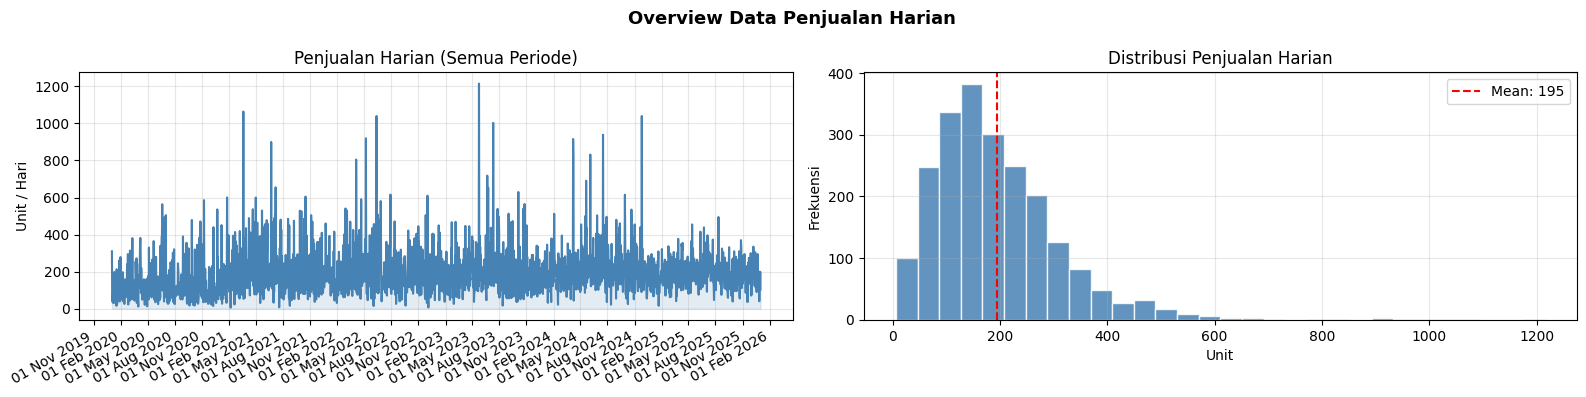

In [ ]:
# Plot data harian
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Overview Data Penjualan Harian", fontsize=13, fontweight='bold')

ax = axes[0]
# Menggunakan main_data sebagai dataset harian
ax.plot(main_data.index, main_data['Sales'], color='steelblue', lw=1.5)
ax.fill_between(main_data.index, main_data['Sales'], alpha=0.15, color='steelblue')

# Mengubah format tanggal agar menampilkan Tanggal, Bulan, dan Tahun
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
# Mengatur kemunculan label tanggal di sumbu X (misal: setiap 3 bulan agar tidak menumpuk)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.set_title("Penjualan Harian (Semua Periode)")
ax.set_ylabel("Unit / Hari"); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(main_data['Sales'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(main_data['Sales'].mean(), color='red', ls='--', lw=1.5,
           label=f"Mean: {main_data['Sales'].mean():.0f}")
ax.set_title("Distribusi Penjualan Harian")
ax.set_xlabel("Unit"); ax.set_ylabel("Frekuensi")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
main_data.head()

,Sales,Hari,Bulan
Tgl Faktur,,,
2020-01-01,310,1,1
2020-01-02,43,2,1
2020-01-03,59,3,1
2020-01-04,34,4,1
2020-01-05,121,5,1


In [ ]:
print(len(main_data))
print(main_data['Sales'].describe())

2192
count    2192.000000
mean      194.937044
std       123.667561
min         6.000000
25%       112.000000
50%       170.000000
75%       251.000000
max      1215.000000
Name: Sales, dtype: float64


In [ ]:
# Cek distribusi Sales
print("Berapa hari dengan Sales < 50?", (main_data['Sales'] < 50).sum())
print("Berapa hari dengan Sales < 20?", (main_data['Sales'] < 20).sum())

# Cek apakah ada hari-hari kosong (weekend/libur tanpa transaksi)
print("\nContoh 20 nilai Sales terkecil:")
print(main_data['Sales'].nsmallest(20).values)

# Cek gap tanggal
date_diff = main_data.index.to_series().diff().dt.days
print("\nGap tanggal (selain 1 hari):")
print(date_diff[date_diff > 1].value_counts().head(10))

Berapa hari dengan Sales < 50? 106
Berapa hari dengan Sales < 20? 14

Contoh 20 nilai Sales terkecil:
[ 6  7  8 12 13 15 15 16 16 16 17 17 17 17 21 21 21 22 22 22]

Gap tanggal (selain 1 hari):
Series([], Name: count, dtype: int64)


In [ ]:
print("Berapa hari bernilai PERSIS 25?", (main_data['Sales'] == 25).sum())
print("Sebelum winsorize, berapa hari Sales == 0?")

# Cek di df_clean sebelum aggregasi
daily_check = (
    df_clean[['Tgl Faktur','Sum of Kuantitas']]
    .groupby('Tgl Faktur')['Sum of Kuantitas'].sum()
)
print("Sales == 0:", (daily_check == 0).sum())
print("Sales < 25:", (daily_check < 25).sum())
print("\nNilai terkecil asli (sebelum winsorize):")
print(daily_check.nsmallest(20).values)

Berapa hari bernilai PERSIS 25? 4
Sebelum winsorize, berapa hari Sales == 0?
Sales == 0: 0
Sales < 25: 22

Nilai terkecil asli (sebelum winsorize):
[ 6  7  8 12 13 15 15 16 16 16 17 17 17 17 21 21 21 22 22 22]


In [ ]:
# HANDLING OUTLIERS
LOWER_PERCENTILE = 0.01
UPPER_PERCENTILE = 0.99

lower_bound = main_data['Sales'].quantile(LOWER_PERCENTILE)
upper_bound = main_data['Sales'].quantile(UPPER_PERCENTILE)

print(f"\nBatas Bawah ({LOWER_PERCENTILE*100}%) : {lower_bound:.0f} unit")
print(f"Batas Atas  ({UPPER_PERCENTILE*100}%) : {upper_bound:.0f} unit")

outliers_bawah = (main_data['Sales'] < lower_bound).sum()
outliers_atas  = (main_data['Sales'] > upper_bound).sum()
print(f"Ditemukan {outliers_bawah} anomali bawah dan {outliers_atas} anomali atas.")

# Eksekusi Winsorization
main_data['Sales'] = main_data['Sales'].clip(lower=lower_bound, upper=upper_bound)


Batas Bawah (1.0%) : 6 unit
Batas Atas  (99.0%) : 145 unit
Ditemukan 11 anomali bawah dan 14 anomali atas.


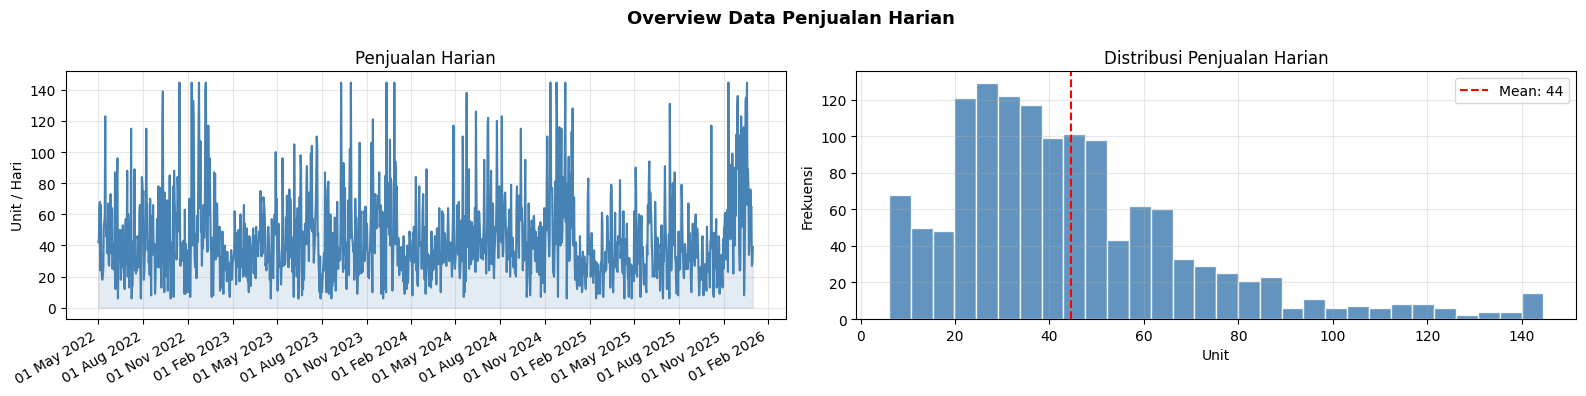

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Overview Data Penjualan Harian", fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(main_data.index, main_data['Sales'], color='steelblue', lw=1.5)
ax.fill_between(main_data.index, main_data['Sales'], alpha=0.15, color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title("Penjualan Harian")
ax.set_ylabel("Unit / Hari"); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(main_data['Sales'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(main_data['Sales'].mean(), color='red', ls='--', lw=1.5,
           label=f"Mean: {main_data['Sales'].mean():.0f}")
ax.set_title("Distribusi Penjualan Harian")
ax.set_xlabel("Unit"); ax.set_ylabel("Frekuensi")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

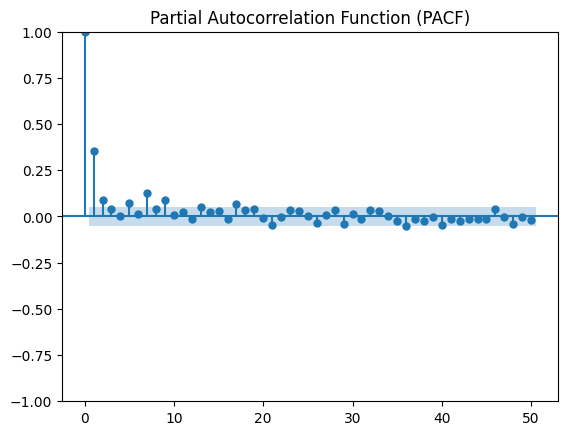

In [ ]:
import statsmodels.api as sm

# Cek korelasi data penjualan dengan dirinya sendiri di masa lalu (Autocorrelation)
fig = sm.graphics.tsa.plot_pacf(main_data['Sales'], lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [ ]:
import plotly.graph_objects as go

# Membuat kanvas Plotly
fig = go.Figure()

# 1. TRACE PENJUALAN: Grafik Area (Di bawah)
fig.add_trace(go.Scatter(
    x=daily_sales.index,
    y=daily_sales['Sum of Kuantitas'],
    fill='tozeroy',            # Mengisi area ke bawah (ke sumbu Y=0)
    mode='lines',
    line=dict(color='teal', width=1),
    name='Penjualan Harian',
    opacity=0.6
))

# 2. TRACE STOK: Grafik Garis (Di atas)
fig.add_trace(go.Scatter(
    x=daily_stock.index,
    y=daily_stock['Stok'],
    mode='lines',
    line=dict(color='orange', width=2),
    name='Sisa Stok Gudang'
))

# 3. PENYESUAIAN TAMPILAN (Layout)
fig.update_layout(
    title=dict(
        text='Perbandingan Penjualan Harian vs Sisa Stok Barang (Interaktif)',
        font=dict(size=20, color='black'),
        y=0.95, x=0.5, xanchor='center', yanchor='top'
    ),
    xaxis_title='Tanggal',
    yaxis_title='Kuantitas (Unit)',

    # Hovermode 'x unified' memunculkan garis vertikal dan
    # menampilkan angka stok & penjualan sekaligus di hari yang sama saat disorot kursor
    hovermode='x unified',

    template='plotly_white', # Tema latar belakang putih bersih

    # Menaruh posisi legend di atas agar area grafik lebih luas
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="right", x=1
    ),

    # Menambahkan slider waktu (opsional, sangat berguna untuk time-series panjang)
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1B", step="month", stepmode="backward"),
                dict(count=6, label="6B", step="month", stepmode="backward"),
                dict(count=1, label="1T", step="year", stepmode="backward"),
                dict(step="all", label="Semua")
            ])
        ),
        rangeslider=dict(visible=True), # Munculkan mini-map/slider di bagian bawah
        type="date"
    )
)

# Menampilkan grafik interaktif
fig.show()

NameError: name 'daily_sales' is not defined

In [ ]:
#LOOK_BACK     = 14   # Menggunakan 14 hari ke belakang
#FORECAST_DAYS = 7    # Memprediksi 7 hari ke depan
#EPOCHS        = 300
#BATCH_SIZE    = 64

In [ ]:
# FEATURE ENGINEERING & SLIDING WINDOW

# 1. Tambah Fitur Kalender
main_data = main_data.copy()
main_data['DayOfWeek'] = main_data.index.dayofweek
main_data['Is_Weekend'] = main_data['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
main_data['DayOfMonth'] = main_data.index.day
main_data['Month'] = main_data.index.month
main_data['Is_Payday'] = main_data['DayOfMonth'].apply(lambda x: 1 if x >= 25 or x <= 5 else 0)
main_data['Rolling_Mean_7'] = main_data['Sales'].shift(1).rolling(window=7).mean()
main_data['Rolling_Std_7']  = main_data['Sales'].shift(1).rolling(window=7).std()

# Isi baris kosong akibat efek rolling
main_data.bfill(inplace=True)

# Update fitur
fitur_kolom = ['Sales', 'DayOfWeek', 'Is_Weekend', 'DayOfMonth', 'Month', 'Is_Payday', 'Rolling_Mean_7', 'Rolling_Std_7']
NUM_FEATURES = len(fitur_kolom)
# Cek kolom
print("Kolom yang tersedia saat ini:", main_data.columns.tolist())


# 2. Scaling (Pisahkan Scaler X dan y)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Split batas index untuk scaling (mencegah data leakage)
n_total = len(main_data)
train_end_idx = int(n_total * 0.70)

# Fit scaler pakai data train saja
scaler_X.fit(main_data[fitur_kolom].iloc[:train_end_idx])
scaler_y.fit(main_data[['Sales']].iloc[:train_end_idx])

# Transform seluruh data
data_X_scaled = scaler_X.transform(main_data[fitur_kolom])
data_y_scaled = scaler_y.transform(main_data[['Sales']])

# 3. Sliding Window Multivariate
LOOK_BACK = 28
FORECAST_DAYS = 7

def make_dataset_multivariate(data_x, data_y, look_back, forecast_days):
    X, y = [], []
    for i in range(len(data_x) - look_back - forecast_days + 1):
        X.append(data_x[i : i + look_back, :]) # Ambil semua kolom fitur
        y.append(data_y[i + look_back : i + look_back + forecast_days, 0]) # Hanya ambil target Sales
    return np.array(X), np.array(y)

X_all, y_all = make_dataset_multivariate(data_X_scaled, data_y_scaled, LOOK_BACK, FORECAST_DAYS)

# 4. Bagi Data (Train, Val, Test)
n_window = len(X_all)
train_end = int(n_window * 0.70)
val_end   = int(n_window * 0.85)

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print(f"Bentuk X_train: {X_train.shape} (Sampel, Look Back, Fitur)")

Kolom yang tersedia saat ini: ['Sales', 'Hari', 'Bulan', 'DayOfWeek', 'Is_Weekend', 'DayOfMonth', 'Month', 'Is_Payday', 'Rolling_Mean_7', 'Rolling_Std_7']
Bentuk X_train: (1510, 28, 8) (Sampel, Look Back, Fitur)


In [ ]:
main_data.head()

,Sales,Hari,Bulan,DayOfWeek,Is_Weekend,DayOfMonth,Month,Is_Payday,Rolling_Mean_7,Rolling_Std_7
Tgl Faktur,,,,,,,,,,
2020-01-01,310,1,1,2,0,1,1,1,100.0,98.94106
2020-01-02,43,2,1,3,0,2,1,1,100.0,98.94106
2020-01-03,59,3,1,4,0,3,1,1,100.0,98.94106
2020-01-04,34,4,1,5,1,4,1,1,100.0,98.94106
2020-01-05,121,5,1,6,1,5,1,1,100.0,98.94106


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
#MODEL SEQ2SEQ LSTM MULTIVARIATE
EPOCHS = 200
BATCH_SIZE = 64

enc_input = Input(shape=(LOOK_BACK, NUM_FEATURES), name="encoder_input")
enc_out = LSTM(128, recurrent_dropout=0.1, name="encoder_lstm")(enc_input)

enc_out   = Dropout(0.2, name="encoder_dropout")(enc_out)

dec_rep   = RepeatVector(FORECAST_DAYS, name="repeat_vector")(enc_out)
dec_out = LSTM(128, recurrent_dropout=0.1, return_sequences=True, name="decoder_lstm")(dec_rep)
dec_out   = Dropout(0.2, name="decoder_dropout")(dec_out)
output    = TimeDistributed(Dense(1), name="output")(dec_out)

model = Model(enc_input, output)

optimizer_custom = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(optimizer=optimizer_custom, loss=Huber(delta=1.0))

model.summary()

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # LR dikali 0.5 setiap triggered
    patience=10,       # Tunggu 10 epoch sebelum turunkan LR
    min_lr=1e-6,
    verbose=1
)

es = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es, lr_scheduler],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 128)            │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 7, 128)         │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout (Dropout)       │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 7, 1)           │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,857 (788.50 KB)

 Trainable params: 201,857 (788.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 0.0089 - val_loss: 0.0073 - learning_rate: 5.0000e-04
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0063 - val_loss: 0.0068 - learning_rate: 5.0000e-04
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 0.0061 - val_loss: 0.0066 - learning_rate: 5.0000e-04
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0059 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0059 - val_loss: 0.0065 - learning_rate: 5.0000e-04
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0058 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0058 - val_loss: 0.0063 - learning_rate: 5.0000e-04
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0057 - val_loss: 0.0063 - learning_rate: 5.0000e-04
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0057 - val_loss: 0.006

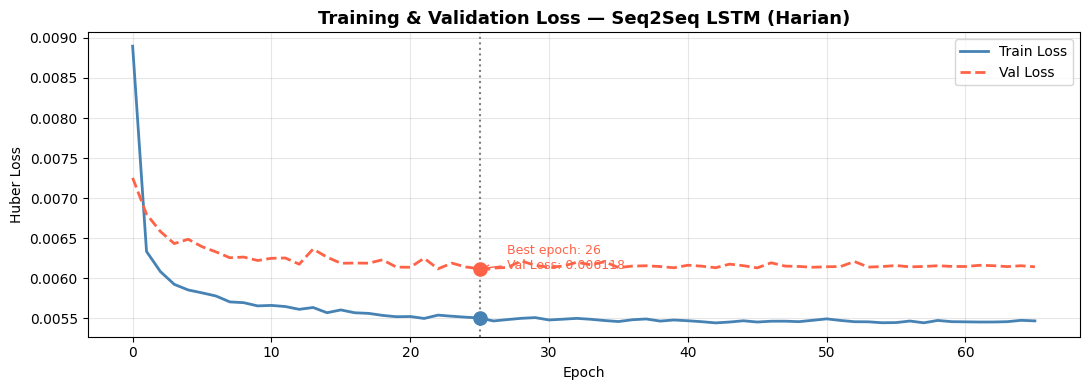

In [ ]:

# ── PLOT LOSS CURVE ────────────────────────────────────────
best_epoch = int(np.argmin(history.history['val_loss']))
best_train = history.history['loss'][best_epoch]
best_val   = history.history['val_loss'][best_epoch]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue', lw=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='tomato',    lw=2, ls='--')
ax.axvline(best_epoch, color='gray', ls=':', lw=1.5)
ax.scatter(best_epoch, best_val,   color='tomato',    s=90, zorder=5)
ax.scatter(best_epoch, best_train, color='steelblue', s=90, zorder=5)

offset = max(len(history.history['loss']) * 0.03, 1)
ax.annotate(f'Best epoch: {best_epoch+1}\nVal Loss: {best_val:.6f}',
            xy=(best_epoch, best_val),
            xytext=(best_epoch + offset, best_val),
            fontsize=9, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato', lw=1))

# Mengubah judul menjadi Harian
ax.set_title("Training & Validation Loss — Seq2Seq LSTM (Harian)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Huber Loss") # Disesuaikan karena pakai Huber Loss
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# EVALUASI MODEL (WAPE & sMAPE)

# 1. Definisi Fungsi Metrik Alternatif
def wape(actual, predicted):
    denominator = np.sum(np.abs(actual))
    if denominator == 0: # Mencegah error pembagian dengan nol
        return 0.0
    return (np.sum(np.abs(actual - predicted)) / denominator) * 100

def smape(actual, predicted):
    epsilon = 1e-10 # Mencegah pembagian dengan nol mutlak
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0 + epsilon
    return np.mean(np.abs(actual - predicted) / denominator) * 100

# 2. Update Fungsi Compute Metrics
def compute_metrics(true, pred, label):
    # Flatten array untuk memastikan perhitungan 1D
    true_f = true.flatten()
    pred_f = pred.flatten()

    rmse = np.sqrt(mean_squared_error(true_f, pred_f))
    mae  = mean_absolute_error(true_f, pred_f)
    wp   = wape(true_f, pred_f)
    smp  = smape(true_f, pred_f)

    print(f"  {label:8s} → RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | WAPE: {wp:6.2f}% | sMAPE: {smp:6.2f}%")
    return rmse, mae, wp, smp

# Fungsi pembantu untuk mengatasi 3 Dimensi (Tetap dipertahankan)
def inverse_y(scaler, arr):
    samples = arr.shape[0]
    timesteps = arr.shape[1]
    return scaler.inverse_transform(arr.reshape(-1, 1)).reshape(samples, timesteps)

# Prediksi model (Kode prediksimu tetap sama)
y_train_pred = np.clip(model.predict(X_train, verbose=0), 0, None)
y_val_pred   = np.clip(model.predict(X_val,   verbose=0), 0, None)
y_test_pred  = np.clip(model.predict(X_test,  verbose=0), 0, None)

y_train_pred_inv = inverse_y(scaler_y, y_train_pred)
y_val_pred_inv   = inverse_y(scaler_y, y_val_pred)
y_test_pred_inv  = inverse_y(scaler_y, y_test_pred)

y_train_true_inv = inverse_y(scaler_y, y_train)
y_val_true_inv   = inverse_y(scaler_y, y_val)
y_test_true_inv  = inverse_y(scaler_y, y_test)

print("\n--- Akurasi Model Evaluasi Baru ---")
# Menampung 4 variabel (RMSE, MAE, WAPE, sMAPE)
r_tr, m_tr, wp_tr, smp_tr = compute_metrics(y_train_true_inv, y_train_pred_inv, "TRAIN")
r_vl, m_vl, wp_vl, smp_vl = compute_metrics(y_val_true_inv,   y_val_pred_inv,   "VAL")
r_ts, m_ts, wp_ts, smp_ts = compute_metrics(y_test_true_inv,  y_test_pred_inv,  "TEST")


--- Akurasi Model Evaluasi Baru ---
  TRAIN    → RMSE:   125.86 | MAE:    93.42 | WAPE:  48.88% | sMAPE:  50.45%
  VAL      → RMSE:   133.74 | MAE:    89.49 | WAPE:  40.80% | sMAPE:  40.51%
  TEST     → RMSE:    78.90 | MAE:    63.26 | WAPE:  31.94% | sMAPE:  33.14%


NameError: name 'mp_tr' is not defined

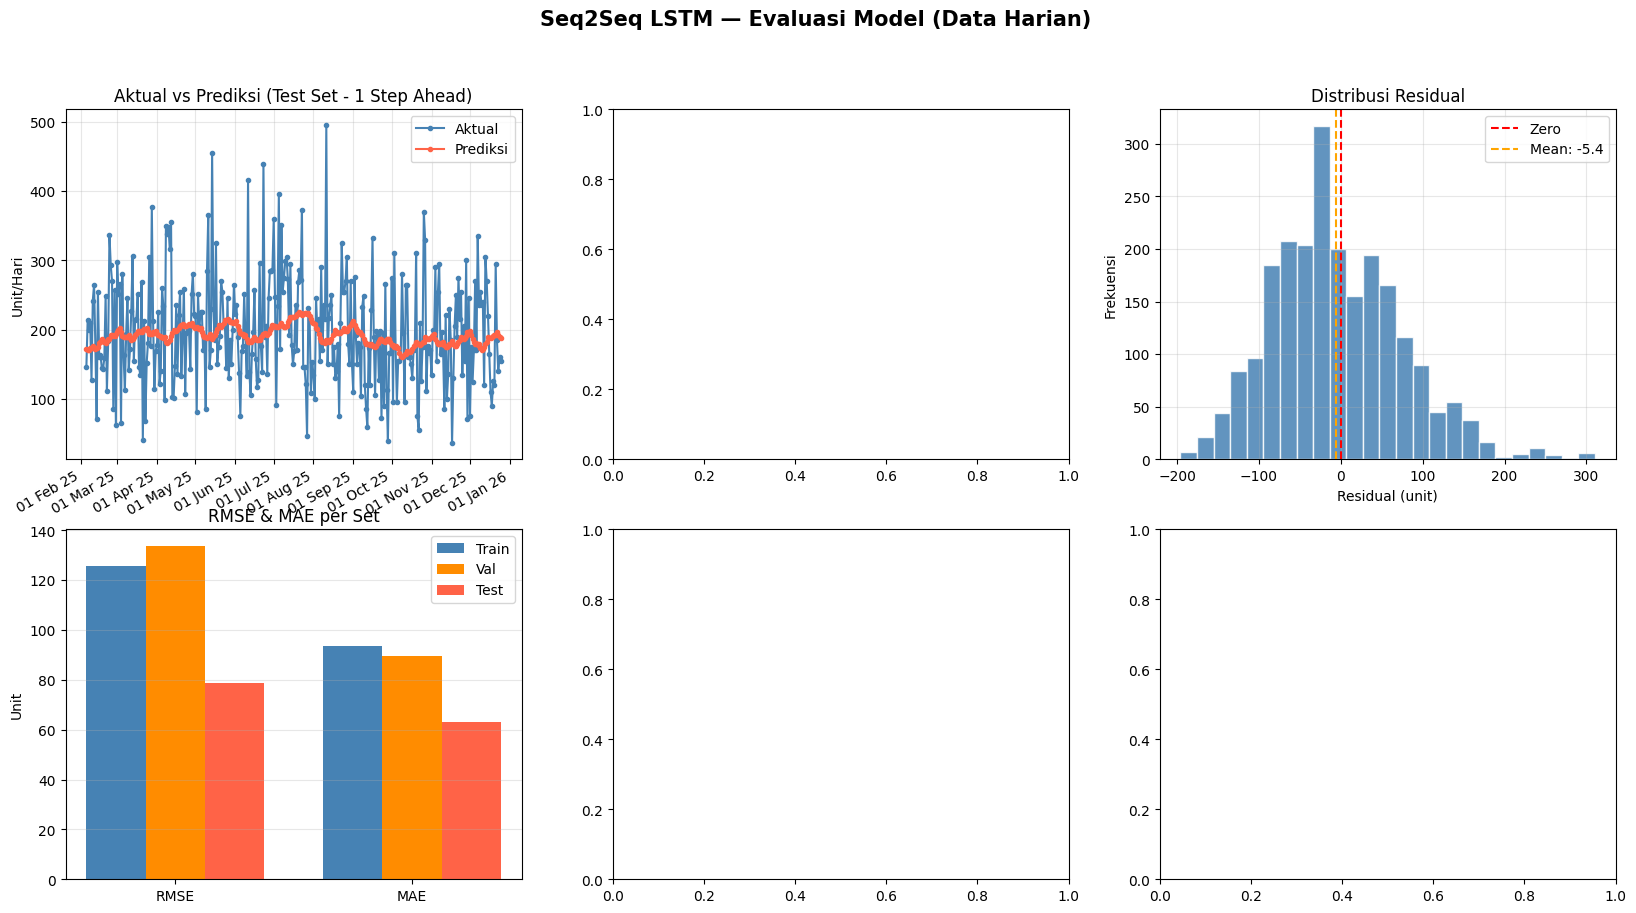

In [ ]:
# PLOT EVALUASI MODEL
# 1. Susun data flat
actual_flat = y_test_true_inv.flatten()
pred_flat = y_test_pred_inv.flatten()

# 2. Susun data line
dates_line, actual_line, pred_line = [], [], []
for i in range(len(X_test)):
    # Menggunakan index dari main_data
    global_idx = val_end + i + LOOK_BACK
    if global_idx < len(main_data):
        dates_line.append(main_data.index[global_idx])
        actual_line.append(y_test_true_inv[i, 0]) # Gunakan _inv
        pred_line.append(y_test_pred_inv[i, 0])   # Gunakan _inv

# Plot evaluasi
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Seq2Seq LSTM — Evaluasi Model (Data Harian)", fontsize=15, fontweight='bold')

# Panel 1 – Actual vs Predicted
ax = axes[0, 0]
ax.plot(dates_line, actual_line, label='Aktual',   color='steelblue', lw=1.5, marker='o', ms=3)
ax.plot(dates_line, pred_line,   label='Prediksi', color='tomato',    lw=1.5, marker='o', ms=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
# Atur interval agar tidak terlalu padat (misal tiap 1 bulan)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title("Aktual vs Prediksi (Test Set - 1 Step Ahead)")
ax.set_ylabel("Unit/Hari"); ax.legend(); ax.grid(alpha=0.3)

# Panel 2 – Residual
ax = axes[0, 2]
residuals = actual_flat - pred_flat
ax.hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', lw=1.5, ls='--', label='Zero')
ax.axvline(residuals.mean(), color='orange', lw=1.5, ls='--', label=f'Mean: {residuals.mean():.1f}')
ax.set_title("Distribusi Residual")
ax.set_xlabel("Residual (unit)"); ax.set_ylabel("Frekuensi")
ax.legend(); ax.grid(alpha=0.3)

# Panel 3 – RMSE & MAE
ax = axes[1, 0]
x = np.arange(2); w = 0.25
ax.bar(x - w, [r_tr, m_tr], w, label='Train', color='steelblue')
ax.bar(x,     [r_vl, m_vl], w, label='Val',   color='darkorange')
ax.bar(x + w, [r_ts, m_ts], w, label='Test',  color='tomato')
ax.set_xticks(x); ax.set_xticklabels(['RMSE', 'MAE'])
ax.set_title("RMSE & MAE per Set"); ax.set_ylabel("Unit")
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Panel 4 – MAPE
ax = axes[1, 1]
bars = ax.bar(['Train','Val','Test'], [mp_tr, mp_vl, mp_ts], color=['steelblue','darkorange','tomato'], edgecolor='white')
for bar, val in zip(bars, [mp_tr, mp_vl, mp_ts]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(10, color='green',  ls='--', lw=1, label='Sangat Baik (<10%)')
ax.axhline(20, color='orange', ls='--', lw=1, label='Baik (<20%)')
ax.set_title("MAPE per Set"); ax.set_ylabel("MAPE (%)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# Panel 5 – Ringkasan teks (Sudah diubah jadi format harian)
ax = axes[1, 2]
ax.axis('off')
summary = (
    f"RINGKASAN MODEL\n"
    f"{'─'*38}\n"
    f"Arsitektur   : Seq2Seq LSTM (1 layer)\n"
    f"LSTM Units   : 64\n"
    f"Granularitas : Harian\n"
    f"Look Back    : {LOOK_BACK} hari\n"
    f"Forecast     : {FORECAST_DAYS} hari\n"
    f"{'─'*38}\n"
    f"        RMSE      MAE     MAPE      R²\n"
    f"Train  {r_tr:6.2f}  {m_tr:6.2f}  {mp_tr:5.2f}%  {r2_tr:5.2f}\n"
    f"Val    {r_vl:6.2f}  {m_vl:6.2f}  {mp_vl:5.2f}%  {r2_vl:5.2f}\n"
    f"Test   {r_ts:6.2f}  {m_ts:6.2f}  {mp_ts:5.2f}%  {r2_ts:5.2f}\n"
    f"{'─'*38}\n"
    f"Status : {interpret_mape(mp_ts)}"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes,
        fontsize=10, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# Cek apakah model benar-benar belajar atau stuck
print("Loss epoch pertama:", history.history['loss'][0])
print("Loss epoch terakhir:", history.history['loss'][-1])
print("Total epoch berjalan:", len(history.history['loss']))

# Cek prediksi mentah sebelum inverse transform
y_test_raw = model.predict(X_test[:5], verbose=0)
print("\nPrediksi raw (scaled):", y_test_raw[:3])
print("Actual raw (scaled):", y_test[:3])

# Cek scaler
print("\nScaler y - data min:", scaler_y.data_min_)
print("Scaler y - data max:", scaler_y.data_max_)

Loss epoch pertama: 0.0290018692612648
Loss epoch terakhir: 0.020335398614406586
Total epoch berjalan: 55

Prediksi raw (scaled): [[[0.2605756 ]
  [0.27879617]
  [0.2757833 ]
  [0.27223396]
  [0.27159572]
  [0.27303237]
  [0.2754283 ]]

 [[0.2565203 ]
  [0.2746973 ]
  [0.27152607]
  [0.26781413]
  [0.26701897]
  [0.26832506]
  [0.27062038]]

 [[0.25898218]
  [0.27851096]
  [0.27607226]
  [0.27274346]
  [0.27215338]
  [0.2735758 ]
  [0.27594432]]]
Actual raw (scaled): [[0.21064891 0.32885428 0.30451788 0.32190102 0.17935926 0.37752707
  0.4175083 ]
 [0.32885428 0.30451788 0.32190102 0.17935926 0.37752707 0.4175083
  0.26453665]
 [0.30451788 0.32190102 0.17935926 0.37752707 0.4175083  0.26453665
  0.08027535]]

Scaler y - data min: [24.82]
Scaler y - data max: [600.09]


In [ ]:
# Nilai Sales di X (dari scaler_X) vs y (dari scaler_y) harusnya beda range
print("Sales di X_train (kolom 0), 5 nilai pertama:", X_train[0, :5, 0])
print("Sales di y_train, 5 nilai pertama:", y_train[0, :5])

Sales di X_train (kolom 0), 5 nilai pertama: [0.49573244 0.03160255 0.05941558 0.01595772 0.16719106]
Sales di y_train, 5 nilai pertama: [0.14111635 0.4418447  0.22455543 0.06810715 0.1237332 ]


In [ ]:
print("scaler_X range untuk kolom Sales:")
print("  min:", scaler_X.data_min_[0], "→ max:", scaler_X.data_max_[0])

print("scaler_y range:")
print("  min:", scaler_y.data_min_[0], "→ max:", scaler_y.data_max_[0])

# Cek isi data_y_scaled
print("\ndata_y_scaled min:", data_y_scaled.min())
print("data_y_scaled max:", data_y_scaled.max())
print("Berapa nilai 0.0 di data_y_scaled?", (data_y_scaled == 0).sum())

scaler_X range untuk kolom Sales:
  min: 24.82 → max: 600.0900000000001
scaler_y range:
  min: 24.82 → max: 600.0900000000001

data_y_scaled min: 0.0
data_y_scaled max: 1.0
Berapa nilai 0.0 di data_y_scaled? 22


In [ ]:
print("Jumlah nilai 0.0 di data_y_scaled:", (data_y_scaled == 0).sum())
print("Jumlah nilai Sales == 25 di main_data:", (main_data['Sales'] == 25).sum())

# Cek apakah 28 nilai 0.0 ini tersebar merata atau menumpuk di satu periode
zero_idx = np.where(data_y_scaled == 0)[0]
print("\nIndex baris dengan nilai 0.0:")
print(zero_idx)

# Cek apakah menumpuk di test set
print("\nBerapa nilai 0.0 di bagian test (index > val_end)?")
print((data_y_scaled[val_end:] == 0).sum(), "dari", len(data_y_scaled[val_end:]), "baris")

Jumlah nilai 0.0 di data_y_scaled: 22
Jumlah nilai Sales == 25 di main_data: 4

Index baris dengan nilai 0.0:
[  15   17   55   89  111  119  262  274  279  337  342  401  414  565
  601  884  992 1069 1320 1507 1686 1847]

Berapa nilai 0.0 di bagian test (index > val_end)?
1 dari 358 baris


In [ ]:
# Cek apakah sliding window membuat y_train punya banyak nilai aneh
print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("y_train mean:", y_train.mean())
print("y_train shape:", y_train.shape)

# Bandingkan prediksi vs actual dalam skala asli untuk 10 sampel pertama
y_sample_pred = model.predict(X_train[:10], verbose=0)
y_sample_pred_inv = scaler_y.inverse_transform(y_sample_pred.reshape(-1,1)).reshape(10,7)
y_sample_true_inv = scaler_y.inverse_transform(y_train[:10].reshape(-1,1)).reshape(10,7)

print("\nActual (inverse):")
print(y_sample_true_inv[:5])
print("\nPrediksi (inverse):")
print(y_sample_pred_inv[:5])

# Hitung MAPE manual untuk 5 sampel pertama saja
for i in range(5):
    actual = y_sample_true_inv[i]
    pred = y_sample_pred_inv[i]
    mape_i = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"Sampel {i}: actual={actual.mean():.1f}, pred={pred.mean():.1f}, MAPE={mape_i:.1f}%")

y_train min: 0.0
y_train max: 1.0
y_train mean: 0.28574470539019975
y_train shape: (1510, 7)

Actual (inverse):
[[106. 279. 154.  64.  96. 132. 173.]
 [279. 154.  64.  96. 132. 173.  77.]
 [154.  64.  96. 132. 173.  77.  45.]
 [ 64.  96. 132. 173.  77.  45. 197.]
 [ 96. 132. 173.  77.  45. 197. 148.]]

Prediksi (inverse):
[[123.53469 133.32068 131.89885 129.78407 128.80879 128.81459 129.37283]
 [124.07417 133.46965 131.6861  129.31001 128.16396 128.06393 128.5591 ]
 [128.52707 138.09253 136.17621 133.68843 132.49742 132.39891 132.9196 ]
 [132.26271 141.34215 138.93567 136.15067 134.82396 134.68587 135.21619]
 [131.36087 140.76465 138.70708 136.20654 135.09612 135.12172 135.77745]]
Sampel 0: actual=143.4, pred=129.4, MAPE=35.4%
Sampel 1: actual=139.3, pred=129.0, MAPE=43.6%
Sampel 2: actual=105.9, pred=133.5, MAPE=66.6%
Sampel 3: actual=112.0, pred=136.2, MAPE=69.5%
Sampel 4: actual=124.0, pred=136.1, MAPE=54.3%


In [ ]:
print("Tanggal awal main_data:", main_data.index[0])
print("Tanggal akhir main_data:", main_data.index[-1])

# Lihat penjualan per tahun
main_data['Year'] = main_data.index.year
print("\nRata-rata Sales per tahun:")
print(main_data.groupby('Year')['Sales'].agg(['mean','std','min','max']))

Tanggal awal main_data: 2020-01-01 00:00:00
Tanggal akhir main_data: 2025-12-31 00:00:00

Rata-rata Sales per tahun:
            mean        std  min   max
Year                                  
2020  132.407104  46.883544   26   586
2021  211.789041  59.881035   37   505
2022  196.649315  56.685830   31   505
2023  201.969863  56.346960   61   450
2024  214.459016  71.053229   85  1040
2025  191.509589  42.648423   36   321


In [ ]:
# Lihat loss curve detail
print("Loss per 10 epoch:")
for i in range(0, len(history.history['loss']), 10):
    print(f"  Epoch {i+1:3d}: train={history.history['loss'][i]:.5f}, val={history.history['val_loss'][i]:.5f}")

# Cek prediksi sekarang masih flat atau sudah bergerak
y_sample_pred = model.predict(X_train[:10], verbose=0)
y_sample_pred_inv = scaler_y.inverse_transform(y_sample_pred.reshape(-1,1)).reshape(10,7)
print("\nPrediksi 5 sampel pertama (inverse):")
print(y_sample_pred_inv[:5].round(1))
print("\nActual 5 sampel pertama (inverse):")
y_sample_true_inv = scaler_y.inverse_transform(y_train[:10].reshape(-1,1)).reshape(10,7)
print(y_sample_true_inv[:5].round(1))

Loss per 10 epoch:
  Epoch   1: train=0.02900, val=0.02215
  Epoch  11: train=0.02083, val=0.01856
  Epoch  21: train=0.02064, val=0.01872
  Epoch  31: train=0.02044, val=0.01861
  Epoch  41: train=0.02035, val=0.01856
  Epoch  51: train=0.02033, val=0.01867

Prediksi 5 sampel pertama (inverse):
[[123.5 133.3 131.9 129.8 128.8 128.8 129.4]
 [124.1 133.5 131.7 129.3 128.2 128.1 128.6]
 [128.5 138.1 136.2 133.7 132.5 132.4 132.9]
 [132.3 141.3 138.9 136.2 134.8 134.7 135.2]
 [131.4 140.8 138.7 136.2 135.1 135.1 135.8]]

Actual 5 sampel pertama (inverse):
[[106. 279. 154.  64.  96. 132. 173.]
 [279. 154.  64.  96. 132. 173.  77.]
 [154.  64.  96. 132. 173.  77.  45.]
 [ 64.  96. 132. 173.  77.  45. 197.]
 [ 96. 132. 173.  77.  45. 197. 148.]]


In [ ]:
# Cek apakah X_train benar-benar mengandung informasi yang relevan
# dengan cara lihat korelasi fitur vs target

import pandas as pd

# Ambil nilai Sales dari X (kolom 0) dan bandingkan dengan y
x_sales = X_train[:, -1, 0]  # nilai Sales di timestep TERAKHIR window
y_next  = y_train[:, 0]       # nilai Sales hari pertama setelah window

corr = np.corrcoef(x_sales, y_next)[0,1]
print(f"Korelasi Sales kemarin vs Sales besok: {corr:.4f}")

# Cek juga lag lainnya
for lag in range(1, 8):
    x_lag = X_train[:, -lag, 0]
    c = np.corrcoef(x_lag, y_next)[0,1]
    print(f"Korelasi Sales lag-{lag} vs Sales besok: {c:.4f}")

# Cek apakah data X dan y sudah ter-align dengan benar
print("\nSales di X_train[-1] (hari terakhir window), 5 pertama:")
print(scaler_y.inverse_transform(X_train[:5, -1, 0:1]))
print("\nSales di y_train (hari pertama forecast), 5 pertama:")
print(scaler_y.inverse_transform(y_train[:5, 0:1]))

Korelasi Sales kemarin vs Sales besok: 0.3084
Korelasi Sales lag-1 vs Sales besok: 0.3084
Korelasi Sales lag-2 vs Sales besok: 0.1245
Korelasi Sales lag-3 vs Sales besok: 0.0765
Korelasi Sales lag-4 vs Sales besok: 0.0265
Korelasi Sales lag-5 vs Sales besok: 0.0464
Korelasi Sales lag-6 vs Sales besok: 0.0329
Korelasi Sales lag-7 vs Sales besok: 0.1117

Sales di X_train[-1] (hari terakhir window), 5 pertama:
[[46.]
 [57.]
 [28.]
 [47.]
 [88.]]

Sales di y_train (hari pertama forecast), 5 pertama:
[[57.]
 [28.]
 [47.]
 [88.]
 [20.]]


In [ ]:
# Cek 30 hari pertama datamu
print(main_data['Sales'].head(30).to_string())

# Cek apakah ada pola mingguan yang hilang
main_data['DayOfWeek'] = main_data.index.dayofweek
print("\nRata-rata Sales per hari dalam seminggu:")
print(main_data.groupby('DayOfWeek')['Sales'].mean().round(1))

Tgl Faktur
2020-01-01    143
2020-01-02     79
2020-01-03     83
2020-01-04    111
2020-01-05     98
2020-01-06    115
2020-01-07     95
2020-01-08    108
2020-01-09    108
2020-01-10     87
2020-01-11    111
2020-01-12     71
2020-01-13     97
2020-01-14    104
2020-01-15     88
2020-01-16     65
2020-01-17    104
2020-01-18     80
2020-01-19     56
2020-01-20     97
2020-01-21     87
2020-01-22     84
2020-01-23     75
2020-01-24     79
2020-01-25    107
2020-01-26    126
2020-01-27    102
2020-01-28    111
2020-01-29    111
2020-01-30    141

Rata-rata Sales per hari dalam seminggu:
DayOfWeek
0    214.1
1    207.2
2    190.9
3    176.8
4    164.2
5    223.0
6    164.0
Name: Sales, dtype: float64


In [ ]:
weekly_data = main_data[['Sales']].resample('W').sum()
weekly_vals = weekly_data['Sales'].values

corr_w1 = np.corrcoef(weekly_vals[:-1], weekly_vals[1:])[0,1]
corr_w2 = np.corrcoef(weekly_vals[:-2], weekly_vals[2:])[0,1]
corr_w4 = np.corrcoef(weekly_vals[:-4], weekly_vals[4:])[0,1]

print(f"Korelasi lag-1 minggu: {corr_w1:.4f}")
print(f"Korelasi lag-2 minggu: {corr_w2:.4f}")
print(f"Korelasi lag-4 minggu: {corr_w4:.4f}")
print(f"\nJumlah data mingguan: {len(weekly_vals)}")
print(f"\nSampel 10 minggu pertama:")
print(weekly_data.head(10))

Korelasi lag-1 minggu: 0.3474
Korelasi lag-2 minggu: 0.2278
Korelasi lag-4 minggu: 0.1641

Jumlah data mingguan: 193

Sampel 10 minggu pertama:
            Sales
Tgl Faktur       
2022-05-01   42.0
2022-05-08  320.0
2022-05-15  352.0
2022-05-22  320.0
2022-05-29  360.0
2022-06-05  260.0
2022-06-12  369.0
2022-06-19  247.0
2022-06-26  245.0
2022-07-03  306.0
